## SQL CORE QUERYING

PRAGMA

It is used to:
1. modify DB behaviour
2. modify qury database metadata.
3. This command is specific to sqlite3.
4. It basically shows the schema details. Like df.ino in dataframes and desc query in database.
5. 

In [1]:
import numpy as np
import pandas as pd
import seaborn as sb
import sqlite3

In [24]:
#Create a db for data analysis
daConnect = sqlite3.connect('data_analysis.db')
cursor = daConnect.cursor()

In [ ]:
daConnect.commit()
daConnect.close()

In [4]:
titanicDF = sb.load_dataset('titanic')
irisDF = sb.load_dataset('iris')
tipsDF = sb.load_dataset('tips')

In [14]:
titanicDF.to_sql('titanicTbl',daConnect,if_exists='replace',index=False)
irisDF.to_sql('irisTbl',daConnect,if_exists='replace',index=False)
tipsDF.to_sql('tipsTbl',daConnect,if_exists='replace',index=False)

244

In [15]:
#Veiw all tables in database

query = "SELECT *,name FROM sqlite_master where type='table'"
tablesList = pd.read_sql(query,daConnect)

print(tablesList)


    type        name    tbl_name  rootpage  \
0  table  titanicTbl  titanicTbl         2   
1  table     irisTbl     irisTbl         4   
2  table     tipsTbl     tipsTbl        20   

                                                 sql        name  
0  CREATE TABLE "titanicTbl" (\n"survived" INTEGE...  titanicTbl  
1  CREATE TABLE "irisTbl" (\n"sepal_length" REAL,...     irisTbl  
2  CREATE TABLE "tipsTbl" (\n"total_bill" REAL,\n...     tipsTbl  


In [31]:
#How to get the desc of a single table?
query="PRAGMA table_info('irisTbl')"
tableInfo = pd.read_sql(query,daConnect)
print(tableInfo)

query="PRAGMA table_info('titanicTbl')"
tableInfo = pd.read_sql(query,daConnect)
print(tableInfo)

   cid          name  type  notnull dflt_value  pk
0    0  sepal_length  REAL        0       None   0
1    1   sepal_width  REAL        0       None   0
2    2  petal_length  REAL        0       None   0
3    3   petal_width  REAL        0       None   0
4    4       species  TEXT        0       None   0
    cid         name     type  notnull dflt_value  pk
0     0     survived  INTEGER        0       None   0
1     1       pclass  INTEGER        0       None   0
2     2          sex     TEXT        0       None   0
3     3          age     REAL        0       None   0
4     4        sibsp  INTEGER        0       None   0
5     5        parch  INTEGER        0       None   0
6     6         fare     REAL        0       None   0
7     7     embarked     TEXT        0       None   0
8     8        class     TEXT        0       None   0
9     9          who     TEXT        0       None   0
10   10   adult_male  INTEGER        0       None   0
11   11         deck     TEXT        0       N

## SELECT SPECIFIC COLUMNS

In [30]:
## In SQL
query="SELECT SURVIVED,SEX,AGE FROM titanicTbl"
titanicData = pd.read_sql(query,daConnect)
print(f"titanic data from sql {titanicData}")

## IN DATAFRAME
titanic[['survived','sex','age']].head(10)

titanic data from  SQL      survived     sex   age
0           0    male  22.0
1           1  female  38.0
2           1  female  26.0
3           1  female  35.0
4           0    male  35.0
..        ...     ...   ...
886         0    male  27.0
887         1  female  19.0
888         0  female   NaN
889         1    male  26.0
890         0    male  32.0

[891 rows x 3 columns]


,survived,sex,age
0,0,male,22.0
1,1,female,38.0
2,1,female,26.0
3,1,female,35.0
4,0,male,35.0
5,0,male,NaN
6,0,male,54.0
7,0,male,2.0
8,1,female,27.0
9,1,female,14.0


In [35]:
## In SQL
query="SELECT species,sepal_length,petal_length FROM irisTbl"
irisData = pd.read_sql(query,daConnect)
print(f"iris data from  SQL {irisData.tail()}")

## IN DATAFRAME
iris[['species','sepal_length','petal_length']].head(10)

iris data from  SQL        species  sepal_length  petal_length
145  virginica           6.7           5.2
146  virginica           6.3           5.0
147  virginica           6.5           5.2
148  virginica           6.2           5.4
149  virginica           5.9           5.1


,species,sepal_length,petal_length
0,setosa,5.1,1.4
1,setosa,4.9,1.4
2,setosa,4.7,1.3
3,setosa,4.6,1.5
4,setosa,5.0,1.4
5,setosa,5.4,1.7
6,setosa,4.6,1.4
7,setosa,5.0,1.5
8,setosa,4.4,1.4
9,setosa,4.9,1.5


## FILTERING DATA IN SQL TABLE
This is where where command is used. It will allow us to give conditions to the table to filter the data.

In [53]:
## In SQL
query="SELECT distinct species from irisTbl where petal_length > 5.0"
irisData = pd.read_sql(query,daConnect)
print(f"iris data from  SQL {irisData}")

## IN DATAFRAME
#drop_dupliucates() will revome the duplicates from the returmed result, at last
# df.drop_duplicates(keep='first')   # default - keeps the first entry and remove the rest of the duplicates
# df.drop_duplicates(keep='last') #keeps the last entry and remove the rest of the duplicates
# df.drop_duplicates(keep=False)     # removes ALL duplicates, only entries whicg=h are unique will be retaines.
print(iris[iris['petal_length'] > 5]['species'].drop_duplicates())
print(iris['petal_length'].unique())

iris data from  SQL       species
0  versicolor
1   virginica
83     versicolor
100     virginica
Name: species, dtype: str
[1.4 1.3 1.5 1.7 1.6 1.1 1.2 1.  1.9 4.7 4.5 4.9 4.  4.6 3.3 3.9 3.5 4.2
 3.6 4.4 4.1 4.8 4.3 5.  3.8 3.7 5.1 3.  6.  5.9 5.6 5.8 6.6 6.3 6.1 5.3
 5.5 6.7 6.9 5.7 6.4 5.4 5.2]


In [44]:
## In SQL
query1="SELECT embarked,count(*) from titanicTbl group by embarked"
titanicData = pd.read_sql(query1,daConnect)
print(f"{titanicData}")

## IN DATAFRAMES
titanic['embarked'].value_counts()

  embarked  count(*)
0      NaN         2
1        C       168
2        Q        77
3        S       644


embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [60]:
## In SQL
query1="SELECT who,age,pclass,alive from titanicTbl order by age desc"
titanicData = pd.read_sql(query1,daConnect)
print(f"{titanicData.head(10)}")

## IN DATAFRAMES
titanic[['who','age','pclass','alive']].sort_values('age',ascending=False).head(10)

   who   age  pclass alive
0  man  80.0       1   yes
1  man  74.0       3    no
2  man  71.0       1    no
3  man  71.0       1    no
4  man  70.5       3    no
5  man  70.0       2    no
6  man  70.0       1    no
7  man  66.0       2    no
8  man  65.0       1    no
9  man  65.0       3    no


,who,age,pclass,alive
630,man,80.0,1,yes
851,man,74.0,3,no
493,man,71.0,1,no
96,man,71.0,1,no
116,man,70.5,3,no
745,man,70.0,1,no
672,man,70.0,2,no
33,man,66.0,2,no
456,man,65.0,1,no
54,man,65.0,1,no


In [70]:
## In SQL
query1="SELECT who,age,pclass,alive from titanicTbl LIMIT 10"
titanicData = pd.read_sql(query1,daConnect)
print(f"{titanicData}")

#OFFSET is used to tell the sql how many rows to skip in starting and returns the rows from that count
query1="SELECT who,age,pclass,alive from titanicTbl LIMIT 10 OFFSET 20"
titanicData = pd.read_sql(query1,daConnect)
print(f"\n {titanicData}")

## IN DATAFRAMES
print(f"\n {titanic[['who','age','pclass','alive']].iloc[20:30]}")
print(f"\n {titanic[['who','age','pclass','alive']].iloc[20:30]}")

     who   age  pclass alive
0    man  22.0       3    no
1  woman  38.0       1   yes
2  woman  26.0       3   yes
3  woman  35.0       1   yes
4    man  35.0       3    no
5    man   NaN       3    no
6    man  54.0       1    no
7  child   2.0       3    no
8  woman  27.0       3   yes
9  child  14.0       2   yes

      who   age  pclass alive
0    man  35.0       2    no
1    man  34.0       2   yes
2  child  15.0       3   yes
3    man  28.0       1   yes
4  child   8.0       3    no
5  woman  38.0       3   yes
6    man   NaN       3    no
7    man  19.0       1    no
8  woman   NaN       3   yes
9    man   NaN       3    no

       who   age  pclass alive
20    man  35.0       2    no
21    man  34.0       2   yes
22  child  15.0       3   yes
23    man  28.0       1   yes
24  child   8.0       3    no
25  woman  38.0       3   yes
26    man   NaN       3    no
27    man  19.0       1    no
28  woman   NaN       3   yes
29    man   NaN       3    no

       who   age  pclass al

In [76]:
## In SQL
query1="SELECT who as sex,age,pclass as passesngerClass,alive as lifestatus,fare * 1.8 as FareWithTax from titanicTbl LIMIT 10"
titanicData = pd.read_sql(query1,daConnect)
print(f"{titanicData}")

#OFFSET is used to tell the sql how many rows to skip in starting and returns the rows from that count
query1="SELECT who as sex,age,pclass as passesngerClass,alive as lifestatus,fare * 1.8 as FareWithTax from titanicTbl LIMIT 10 OFFSET 20"
titanicData = pd.read_sql(query1,daConnect)
print(f"\n {titanicData}")

## IN DATAFRAMES
titanic_copy = titanic[['who','age','pclass','alive','fare']].copy()
titanic_copy['fare_with_tax']=titanic_copy['fare']*1.8
titanic_copy.head()

     sex   age  passesngerClass lifestatus  FareWithTax
0    man  22.0                3         no     13.05000
1  woman  38.0                1        yes    128.30994
2  woman  26.0                3        yes     14.26500
3  woman  35.0                1        yes     95.58000
4    man  35.0                3         no     14.49000
5    man   NaN                3         no     15.22494
6    man  54.0                1         no     93.35250
7  child   2.0                3         no     37.93500
8  woman  27.0                3        yes     20.03994
9  child  14.0                2        yes     54.12744

      sex   age  passesngerClass lifestatus  FareWithTax
0    man  35.0                2         no     46.80000
1    man  34.0                2        yes     23.40000
2  child  15.0                3        yes     14.45256
3    man  28.0                1        yes     63.90000
4  child   8.0                3         no     37.93500
5  woman  38.0                3        yes    

,who,age,pclass,alive,fare,fare_with_tax
0,man,22.0,3,no,7.2500,13.05000
1,woman,38.0,1,yes,71.2833,128.30994
2,woman,26.0,3,yes,7.9250,14.26500
3,woman,35.0,1,yes,53.1000,95.58000
4,man,35.0,3,no,8.0500,14.49000


In [88]:
## Null values
## In SQL
## In SQL
query1="SELECT who as sex,age,pclass as passesngerClass,alive as lifestatus,fare * 1.8 as FareWithTax from titanicTbl WHERE AGE IS NOT NULL"
titanicData = pd.read_sql(query1,daConnect)
print(f"{titanicData}")

#OFFSET is used to tell the sql how many rows to skip in starting and returns the rows from that count
query1="SELECT who as sex,age,pclass as passesngerClass,alive as lifestatus,fare * 1.8 as FareWithTax from titanicTbl WHERE AGE IS NULL"
titanicData = pd.read_sql(query1,daConnect)
print(f"\n {titanicData}")

## IN DATAFRAMES
titanic_copy = titanic[['who','age','pclass','alive','fare']].copy()
titanic_copy['fare_with_tax']=titanic_copy['fare']*1.8
#Here the any means return rows if any of the 
print(F"\n {titanic_copy[titanic_copy.isna().any(axis=1)].tail()}")
print(F"\n {titanic_copy[titanic_copy.notna().any(axis=1)].tail()}")

       sex   age  passesngerClass lifestatus  FareWithTax
0      man  22.0                3         no     13.05000
1    woman  38.0                1        yes    128.30994
2    woman  26.0                3        yes     14.26500
3    woman  35.0                1        yes     95.58000
4      man  35.0                3         no     14.49000
..     ...   ...              ...        ...          ...
709  woman  39.0                3         no     52.42500
710    man  27.0                2         no     23.40000
711  woman  19.0                1        yes     54.00000
712    man  26.0                1        yes     54.00000
713    man  32.0                3         no     13.95000

[714 rows x 5 columns]

        sex   age  passesngerClass lifestatus  FareWithTax
0      man  None                3         no     15.22494
1      man  None                2        yes     23.40000
2    woman  None                3        yes     13.00500
3      man  None                3         no  

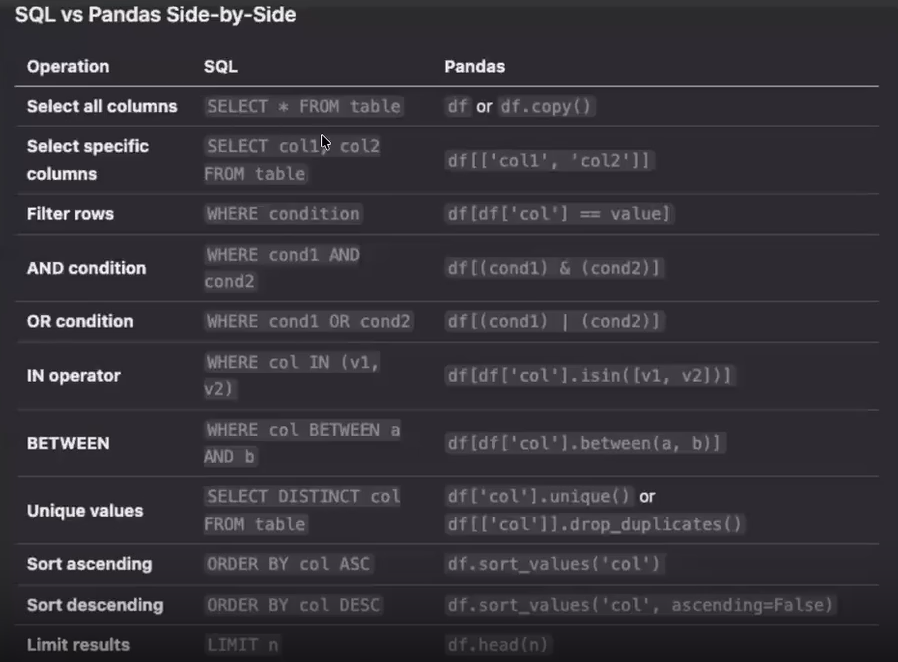
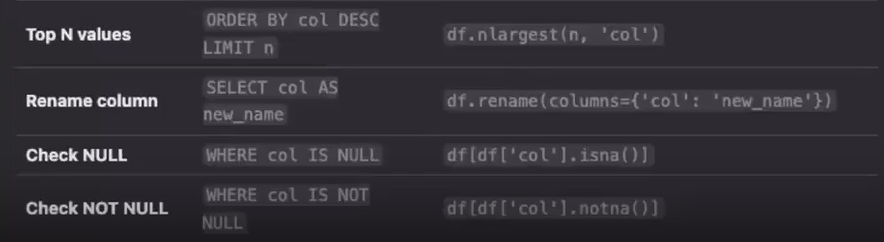